In [2]:
from sklearn import preprocessing
import pandas as pd
import numpy as np
import os

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn

# Librosa (the mother of audio files)
import librosa
import librosa.display
from IPython.display import display
import warnings

from pathlib import Path


warnings.filterwarnings('ignore')
# Cyril data located 2 steps above :
general_path = Path(r"C:\Users\Cyril\Documents\python\jedha\M11_projet\music_genre_classification\gtzan-dataset-music-genre-classification\Data")
pca_sub_path = Path("PCA")
PCA_PATH = general_path / pca_sub_path


file_path = general_path / 'features_30_sec.csv'
data = pd.read_csv(file_path)
data.head()



,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [3]:


cols_toremove = ['filename','length','label']
y_filename = data['filename']
y = data['label']
data2 = data.drop(cols_toremove,axis=1)

# X is w/o columns filename & label 
X = data2.loc[:, data2.columns != 'label']
cols = X.columns    
print(X[:5])
data2.head()




   chroma_stft_mean  chroma_stft_var  rms_mean   rms_var  \
0          0.350088         0.088757  0.130228  0.002827   
1          0.340914         0.094980  0.095948  0.002373   
2          0.363637         0.085275  0.175570  0.002746   
3          0.404785         0.093999  0.141093  0.006346   
4          0.308526         0.087841  0.091529  0.002303   

   spectral_centroid_mean  spectral_centroid_var  spectral_bandwidth_mean  \
0             1784.165850          129774.064525              2002.449060   
1             1530.176679          375850.073649              2039.036516   
2             1552.811865          156467.643368              1747.702312   
3             1070.106615          184355.942417              1596.412872   
4             1835.004266          343399.939274              1748.172116   

   spectral_bandwidth_var  rolloff_mean   rolloff_var  ...  mfcc16_mean  \
0            85882.761315   3805.839606  9.015054e+05  ...     0.752740   
1           213843.755497 

,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,3805.839606,9.015054e+05,...,0.752740,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035
1,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,3550.522098,2.977893e+06,...,0.927998,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282
2,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,3042.260232,7.840345e+05,...,2.451690,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025
3,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,2184.745799,1.493194e+06,...,0.780874,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339
4,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,3579.757627,1.572978e+06,...,-4.520576,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160


In [4]:



#### NORMALIZE X ####

min_max_scaler = preprocessing.MinMaxScaler()
np_scaled = min_max_scaler.fit_transform(X)
X = pd.DataFrame(np_scaled, columns = cols)

N_comp = 12
#### PCA 10 COMPONENTS ####
from sklearn.decomposition import PCA

pca = PCA(n_components=N_comp)
principalComponents = pca.fit_transform(X)
PC_colnames = [f"princ_comp_{i+1}" for i in range(N_comp) ]
principalDf = pd.DataFrame(data = principalComponents, columns = PC_colnames)


# use with X_test:
#PC_test = pca.transform(X_test)

# Sauvegarder l'instance PCA dans un fichier
import joblib
pca_filepath = PCA_PATH / 'pca_model10.pkl'
joblib.dump(pca, pca_filepath)

# concatenate with target label
finalDf = pd.concat([principalDf, y, y2], axis = 1)

pca.explained_variance_ratio_
finalDf.head()
# 44.93 variance explained



NameError: name 'y2' is not defined

,princ_comp_1,princ_comp_2,princ_comp_3,princ_comp_4,princ_comp_5,princ_comp_6,princ_comp_7,princ_comp_8,princ_comp_9,princ_comp_10,princ_comp_11,princ_comp_12
0,-2.783565,-1.029365,-0.522219,-0.115968,0.713896,0.991845,0.353365,0.400635,0.172261,-0.349387,-0.102344,0.372763
1,1.727521,-1.165727,1.348139,-2.460894,2.070007,0.050922,0.085213,0.126410,0.930189,-1.282137,-1.758516,1.281875
2,-2.815019,-1.571601,-0.088108,-1.597084,-0.706319,1.712740,0.533627,0.249661,-0.459833,0.647996,1.176486,0.597190
3,0.345751,-1.480620,-1.524833,-1.898620,1.892882,2.363926,0.225157,0.014581,0.471199,-0.469569,-1.896164,0.484547
4,0.624704,-3.201114,0.136860,-2.214052,-3.253498,-0.042810,1.481521,-0.037387,-1.249848,0.890086,0.274211,-0.081094


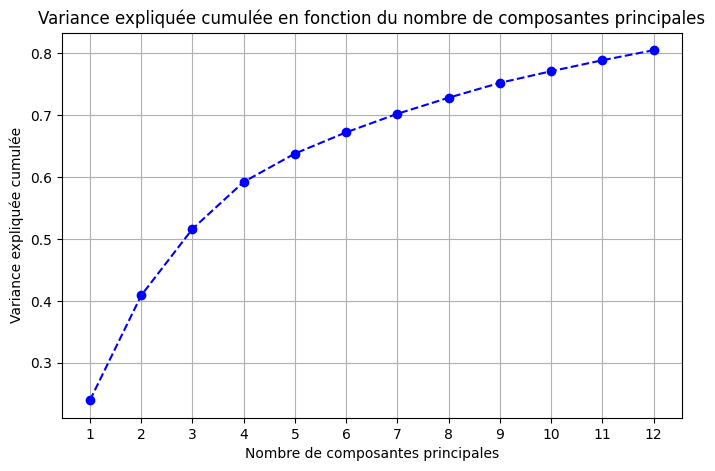

In [10]:



from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from IPython.display import display



import pickle

## Nb of principal components:
N_comp = 12

# Définition du pipeline avec scaler et PCA
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=N_comp))
])



# Entraînement du pipeline sur X
pipeline.fit(X)

# Transformation des données (optionnel)
X_pca = pipeline.fit_transform(X)


# Convertir en DataFrame pour plus de lisibilité (optionnel)
PC_colnames = [f"princ_comp_{i+1}" for i in range(N_comp)]
X_pca_df = pd.DataFrame(data=X_pca, columns=PC_colnames)

display(X_pca_df.head())

# *-Récupérer la variance expliquée par chaque composante principale
explained_variance_ratio = pipeline.named_steps['pca'].explained_variance_ratio_
cumulative_variance = explained_variance_ratio.cumsum()

# Affichage graphique de la variance expliquée cumulée
plt.figure(figsize=(8,5))
plt.plot(range(1, N_comp+1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.title('Variance expliquée cumulée en fonction du nombre de composantes principales')
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance expliquée cumulée')
plt.xticks(range(1, N_comp+1))
plt.grid(True)
plt.show()

# sauver les X_pca : les coord des points dans le repere PCA :
x_pca_path = PCA_PATH / 'X_pca.csv' 
X_pca_labelled = pd.concat([X_pca_df, y_filename, y], axis = 1)
X_pca_labelled.to_csv(x_pca_path, index=False, encoding='utf-8-sig')
# Sauvegarder le pipeline entraîné dans un fichier

pca_pipeline_path = PCA_PATH / 'pca_pipeline.pkl'
with open(pca_pipeline_path, 'wb') as f:
    pickle.dump(pipeline, f)



### #######    
# # Charger le pipeline depuis le fichier
# with open(pca_pipeline_path, 'rb') as f:
#     loaded_pipeline = pickle.load(f)

# Appliquer la transformation sur X_test
#X_test_pca = loaded_pipeline.transform(X_test)




In [13]:
X_pca2 = pipeline.transform(X)
pd.DataFrame(X_pca2)

,0,1,2,3,4,5,6,7,8,9,10,11
0,-2.783565,-1.029365,-0.522219,-0.115968,0.713896,0.991845,0.353365,0.400635,0.172261,-0.349387,-0.102344,0.372763
1,1.727521,-1.165727,1.348139,-2.460894,2.070007,0.050922,0.085213,0.126410,0.930189,-1.282137,-1.758516,1.281875
2,-2.815019,-1.571601,-0.088108,-1.597084,-0.706319,1.712740,0.533627,0.249661,-0.459833,0.647996,1.176486,0.597190
3,0.345751,-1.480620,-1.524833,-1.898620,1.892882,2.363926,0.225157,0.014581,0.471199,-0.469569,-1.896164,0.484547
4,0.624704,-3.201114,0.136860,-2.214052,-3.253498,-0.042810,1.481521,-0.037387,-1.249848,0.890086,0.274211,-0.081094
...,...,...,...,...,...,...,...,...,...,...,...,...
995,-4.858414,-1.539852,0.633166,-1.190824,-0.656577,-0.744381,-0.334401,0.724816,1.087247,0.023919,-0.852335,-0.016032
996,-5.851727,-1.396035,-0.200347,-1.008790,-0.363527,-0.736680,0.158622,0.782728,0.791695,0.855418,-0.399462,-0.327133
997,-5.943121,-1.298427,0.443109,-1.663806,-1.643798,-1.020319,0.492229,0.554715,0.218816,0.835184,-0.079780,-0.379783
998,-0.799352,-1.968622,-0.359356,-2.831155,1.361937,0.119921,0.021799,0.692058,0.381163,-1.103411,-1.478411,-0.447631


In [20]:
type(X)
X_test2 = X.iloc[[0]]
X_test_pca2 = pipeline.transform(X_test2)
X_test_pca2

array([[-2.78356454, -1.02936476, -0.52221913, -0.11596771,  0.71389613,
         0.99184532,  0.35336479,  0.40063462,  0.17226052, -0.34938713,
        -0.10234445,  0.37276332]])

In [24]:
X_test = pd.DataFrame([data2.iloc[0]])
#print(X_test)
type(X_test)
X_test

,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,0.350088,0.088757,0.130228,0.002827,1784.16585,129774.064525,2002.44906,85882.761315,3805.839606,901505.425533,...,0.75274,52.42091,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035


In [11]:

### #######    
# Charger le pipeline depuis le fichier
with open(pca_pipeline_path, 'rb') as f:
    loaded_pipeline = pickle.load(f)
print(loaded_pipeline)
#Appliquer la transformation sur X_test
X_test_pca = loaded_pipeline.transform(X_test)
X_test_pca

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=12))])


array([[ 1156257.29432548,  1014936.41407122,  -101676.09814326,
         -984191.20354578,   176303.41376179,  -874300.96391311,
        -1521526.62336235,   372290.56572296,  1277964.27444335,
         1654743.65754505,  -302416.79372532,  1002678.71892607]])

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=12)
X_pca2 = pca.fit_transform(X_scaled)

# 4. Sauvegarder le modèle PCA et le scaler
joblib.dump(pca, PCA_PATH / 'pca_model_alone.joblib')
joblib.dump(scaler, PCA_PATH / 'scaler.joblib')
pd.DataFrame(X_pca2).head()

NameError: name 'StandardScaler' is not defined

In [ ]:
pca_loaded = joblib.load(PCA_PATH /'pca_model_alone.joblib')
scaler_loaded = joblib.load(PCA_PATH /'scaler.joblib')

X_test_scaled = scaler_loaded.transform(X_test.T)
X_test_pca_alone = pca_loaded.transform(X_test_scaled)
X_test_pca_alone

array([[ 1156257.29432548,  1014936.41407122,  -101676.09814326,
         -984191.20354578,   176303.41376179,  -874300.96391312,
        -1521526.62336235,   372290.56572296,  1277964.27444335,
         1654743.65754506,  -302416.79372532,  1002678.71892607]])